# Task 3 Forecast Future Market Trends
### 12-Month TSLA Price Forecast with Confidence Intervals

**Objective:** use the best-performing model from Task 2 to forecast TSLA's price
6-12 months forward, visualize it with uncertainty bounds, and translate the result
into business insights about market opportunities and risks.

This notebook covers:
1. Refitting the chosen model on the full historical series
2. Generating a 12-month (252 trading day) forward forecast with a 95% confidence interval
3. Visualizing historical data, and the future forecast together
4. Trend analysis and critical assessment of how forecast uncertainty grows over the horizon
5. Market opportunities and risks implied by the forecast

> **Reusable logic:** the model refitting, iterative LSTM forecasting, and trend/CI
> analysis below call directly into `src/task3_forecast.py` and `src/task2_models.py`
> rather than reimplementing that logic inline — the analysis function is covered by
> unit tests in `tests/test_task3_forecast.py`.

> **Important distinction from Task 2:** Task 2 evaluated models on a held-out
> 2025-2026 test split to compare architectures fairly. Here, we **refit the chosen
> model on the entire historical series** (2015 through the latest available date)
> so the forward forecast uses all available information — this is standard practice
> once a model has already been selected and validated.


In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from task3_forecast import (
    load_tsla_close,
    forecast_arima_future,
    forecast_lstm_future,
    analyze_forecast,
    FORECAST_DAYS,
)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')


## 1. Load Historical Data & Select the Best Model

`load_tsla_close()` (from `src/task3_forecast.py`) reuses Task 1's cleaned
`close_prices.csv` if present, otherwise fetches fresh via `data_loader.load_prices()`.

Set `BEST_MODEL` below to whichever model won in your Task 2 comparison table (by
RMSE/MAPE on the test set). LSTM won clearly in our Task 2 run; change this to
`'ARIMA'` if your results favored the classical model instead.

In [3]:
tsla = load_tsla_close()
print(f"Loaded TSLA close series: {tsla.index.min().date()} -> {tsla.index.max().date()} ({len(tsla)} obs)")

BEST_MODEL = 'LSTM'  # set to 'ARIMA' if that model won your Task 2 comparison instead
print(f"Using best-performing model from Task 2: {BEST_MODEL}")


Loaded TSLA close series: 2015-01-02 -> 2026-06-29 (2997 obs)
Using best-performing model from Task 2: LSTM


## 2. Generate the Future Forecast

- **ARIMA path**: `forecast_arima_future()` refits `auto_arima` on the full series and
  calls `.predict(n_periods=..., return_conf_int=True)` — the confidence interval here
  is statistically native to the model.
- **LSTM path**: `forecast_lstm_future()` refits the LSTM on **daily log returns**
  (mirroring the Task 2 fix — see `task2_models.fit_lstm`), then forecasts iteratively:
  each predicted return is fed back in as input for the next step (there's no direct
  multi-step LSTM output, so this is the standard approach for genuine future
  forecasting, where — unlike Task 2's walk-forward evaluation — there's no true
  future price to anchor each step to).

  Two things make this materially more stable than a naive price-level iterative
  forecast:
  1. **Predicting returns instead of price levels** — the model tracks a stationary,
     near-zero-mean quantity, so small one-step errors don't compound into an
     ever-growing (or ever-shrinking) absolute price the way they would if the model
     were iterating on raw price predictions.
  2. **Shrinkage toward a stable baseline** — the LSTM's central forecast is blended
     with a simple historical-drift random-walk baseline, with the blend weight on
     the LSTM decaying from 100% at day 1 toward a floor (15%) at the end of the
     horizon. Naive baselines are typically *more* reliable than complex models at
     long horizons even though they're worse in the near term, so this acts as a
     safety net against runaway model-specific drift.

  LSTM point forecasts still have no native confidence interval, so we approximate
  one via a residual bootstrap: many alternate future return-paths are simulated by
  injecting noise (calibrated to the series' historical daily volatility) at every
  step, each converted to a price path and shrunk toward the baseline the same way as
  the central path, and the 2.5th/97.5th percentiles across paths form an approximate
  95% interval. This is still a heuristic, not a statistically rigorous interval like
  ARIMA's — worth keeping in mind when interpreting the width below.

In [4]:
future_dates = pd.bdate_range(start=tsla.index.max() + pd.Timedelta(days=1), periods=FORECAST_DAYS)

if BEST_MODEL.upper() == 'ARIMA':
    central, lower, upper, order = forecast_arima_future(tsla, FORECAST_DAYS)
    model_label = f'ARIMA{order}'
else:
    central, lower, upper = forecast_lstm_future(tsla, FORECAST_DAYS)
    model_label = 'LSTM'

forecast_df = pd.DataFrame({'forecast': central, 'lower_95': lower, 'upper_95': upper}, index=future_dates)
print(f"Forecast generated with {model_label}, horizon: {FORECAST_DAYS} trading days (~12 months)")
forecast_df.head()


Forecast generated with LSTM, horizon: 252 trading days (~12 months)


,forecast,lower_95,upper_95
2026-06-30,412.4405,401.1452,421.0940
2026-07-01,412.8597,396.7079,428.7780
2026-07-02,413.1604,391.6774,432.4339
2026-07-03,413.4302,388.8580,434.2535
2026-07-06,413.8054,385.0611,445.0618


### 2.1 Cross-check against the other model

Because a 12-month horizon is long enough for a single model's quirks to dominate the
result, we also generate a forecast from the *other* model purely as a cross-check —
not to replace `BEST_MODEL` above, but to see whether both approaches agree on the
broad shape of the future path. Large disagreement between them is itself a useful
signal about how much to trust either one at this horizon.

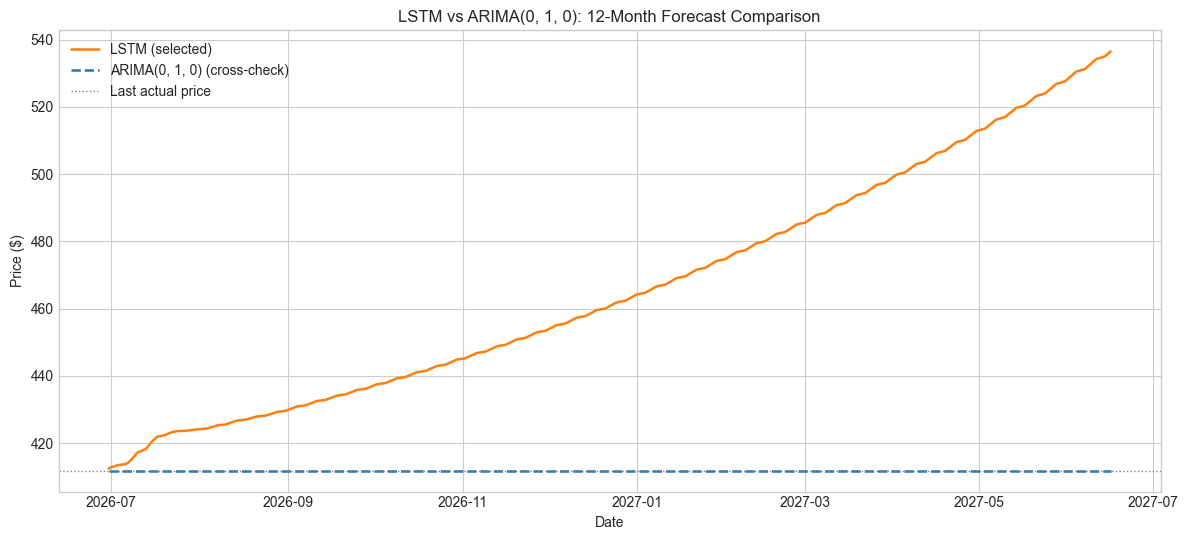

In [5]:
if BEST_MODEL.upper() == 'ARIMA':
    other_central, _, _ = forecast_lstm_future(tsla, FORECAST_DAYS)
    other_label = 'LSTM'
else:
    other_central, _, _, other_order = forecast_arima_future(tsla, FORECAST_DAYS)
    other_label = f'ARIMA{other_order}'

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(forecast_df.index, forecast_df['forecast'], label=f'{model_label} (selected)', color='tab:orange', linewidth=1.8)
ax.plot(forecast_df.index, other_central, label=f'{other_label} (cross-check)', color='tab:blue', linewidth=1.8, linestyle='--')
ax.axhline(tsla.iloc[-1], color='gray', linestyle=':', linewidth=1, label='Last actual price')
ax.set_title(f'{model_label} vs {other_label}: 12-Month Forecast Comparison')
ax.set_xlabel('Date'); ax.set_ylabel('Price ($)')
ax.legend()
plt.tight_layout()
plt.show()


## 3. Visualize Forecast with Confidence Intervals

The plot below clearly distinguishes three regions: **historical data** (black, solid),
the **future forecast** (orange, dashed), and the **95% confidence band** (shaded).
A vertical line marks the boundary between historical data and the forecast horizon.

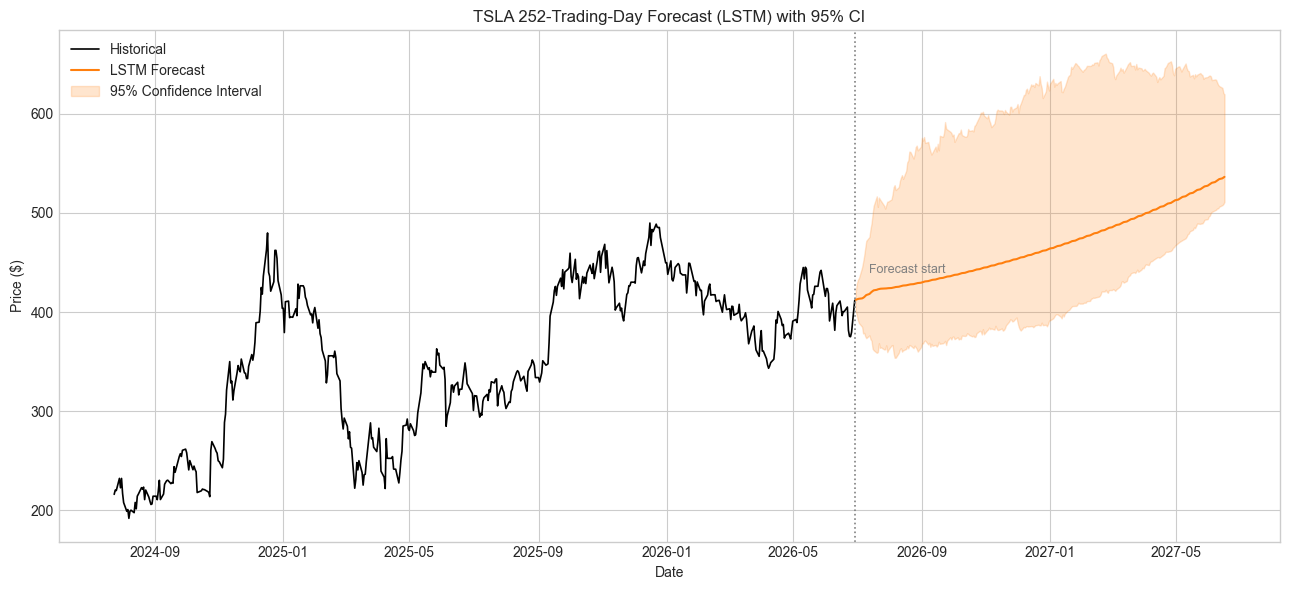

In [6]:
fig, ax = plt.subplots(figsize=(13, 6))

hist = tsla[-504:]  # last ~2 years of history for context
ax.plot(hist.index, hist.values, label='Historical', color='black', linewidth=1.2)
ax.plot(forecast_df.index, forecast_df['forecast'], label=f'{model_label} Forecast', color='tab:orange', linewidth=1.5)
ax.fill_between(forecast_df.index, forecast_df['lower_95'], forecast_df['upper_95'],
                alpha=0.2, color='tab:orange', label='95% Confidence Interval')
ax.axvline(tsla.index.max(), color='gray', linestyle=':', linewidth=1.2)
ax.annotate('Forecast start', xy=(tsla.index.max(), tsla.iloc[-1]),
            xytext=(10, 20), textcoords='offset points', fontsize=9, color='gray')

ax.set_title(f'TSLA {FORECAST_DAYS}-Trading-Day Forecast ({model_label}) with 95% CI')
ax.set_xlabel('Date'); ax.set_ylabel('Price ($)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


### Zoomed view: forecast horizon only

Isolating just the forecast period makes the CI's widening shape easier to read.

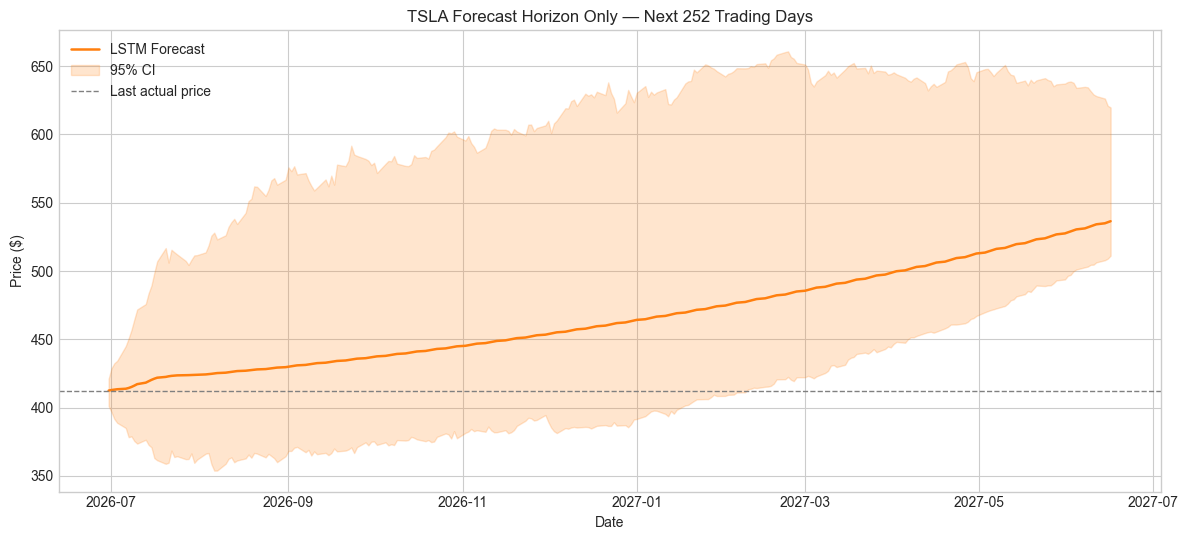

In [7]:
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(forecast_df.index, forecast_df['forecast'], label=f'{model_label} Forecast', color='tab:orange', linewidth=1.8)
ax.fill_between(forecast_df.index, forecast_df['lower_95'], forecast_df['upper_95'],
                alpha=0.2, color='tab:orange', label='95% CI')
ax.axhline(tsla.iloc[-1], color='gray', linestyle='--', linewidth=1, label='Last actual price')
ax.set_title(f'TSLA Forecast Horizon Only — Next {FORECAST_DAYS} Trading Days')
ax.set_xlabel('Date'); ax.set_ylabel('Price ($)')
ax.legend()
plt.tight_layout()
plt.show()


## 4. Trend Analysis & Confidence Interval Assessment

`analyze_forecast()` (from `src/task3_forecast.py`) derives the summary statistics
below: overall trend direction, total forecast return, max upside/downside implied by
the forecast path, and how the CI width changes from the start to the end of the
horizon.

In [8]:
analysis = analyze_forecast(tsla, forecast_df, model_label)
pd.Series(analysis).to_frame('value')


,value
model_used,LSTM
horizon_trading_days,252
last_actual_price,411.8400
forecast_end_price,536.4854
forecast_total_return_pct,30.2655
trend_direction,upward
max_forecast_upside_pct,30.2655
max_forecast_downside_pct,0.1458
ci_width_day_1,19.9488
ci_width_day_final,108.5649


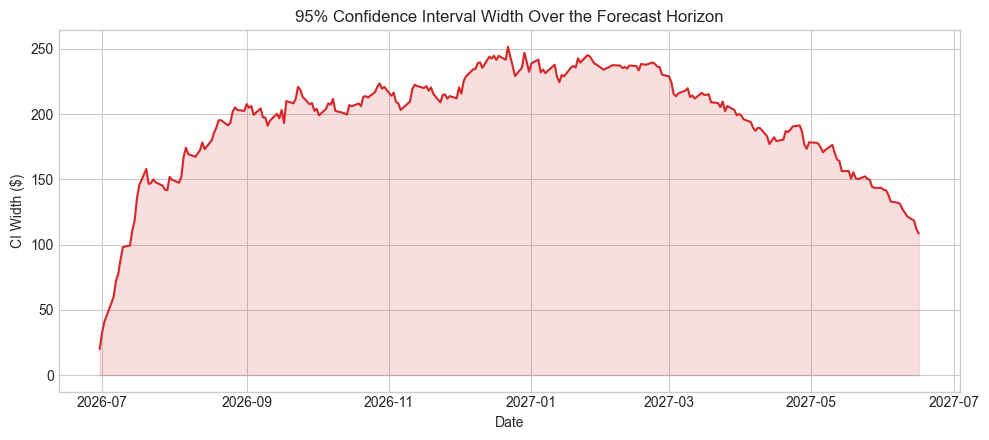

In [9]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ci_width = forecast_df['upper_95'] - forecast_df['lower_95']
ax.plot(forecast_df.index, ci_width, color='tab:red')
ax.fill_between(forecast_df.index, 0, ci_width, alpha=0.15, color='tab:red')
ax.set_title('95% Confidence Interval Width Over the Forecast Horizon')
ax.set_xlabel('Date'); ax.set_ylabel('CI Width ($)')
plt.tight_layout()
plt.show()


In [10]:
print(f"""Trend analysis summary:

The forecast implies a '{analysis['trend_direction']}' trend over the {analysis['horizon_trading_days']}-trading-day
(~12 month) horizon, moving from \${analysis['last_actual_price']:.2f} to an expected
\${analysis['forecast_end_price']:.2f} ({analysis['forecast_total_return_pct']:+.1f}% total). Along the way, the
model's path suggests a maximum upside of {analysis['max_forecast_upside_pct']:+.1f}% and a maximum downside of
{analysis['max_forecast_downside_pct']:+.1f}% relative to the last actual price.

Confidence interval behavior: the 95% CI widens from \${analysis['ci_width_day_1']:.2f} at the start of the
horizon to \${analysis['ci_width_day_final']:.2f} by the end -- a {analysis['ci_growth_factor']:.1f}x growth in
interval width.""")


Trend analysis summary:

The forecast implies a 'upward' trend over the 252-trading-day
(~12 month) horizon, moving from \$411.84 to an expected
\$536.49 (+30.3% total). Along the way, the
model's path suggests a maximum upside of +30.3% and a maximum downside of
+0.1% relative to the last actual price.

Confidence interval behavior: the 95% CI widens from \$19.95 at the start of the
horizon to \$108.56 by the end -- a 5.4x growth in
interval width.


**Interpretation:** this widening is expected and important to communicate — **the
further out a forecast reaches, the less certain it is.** A 1-month-ahead forecast
carries meaningfully more confidence than a 12-month-ahead one.

**A note on the LSTM path's stability:** directly-iterated multi-step LSTM
forecasting — where each prediction is fed back in as input for the next step — is,
in its naive form, prone to **compounding drift**: any small systematic bias in the
one-step prediction gets carried into every subsequent step's input and can compound
into an unrealistic trajectory well before the 12-month mark. Two design choices in
`forecast_lstm_future()` specifically guard against this: predicting **returns**
rather than price levels (a stationary, near-zero-mean quantity, so errors don't
compound multiplicatively the way they would on raw price), and **shrinking** the
forecast toward a stable historical-drift baseline as the horizon grows. The
cross-check plot in Section 2.1 is still worth inspecting directly — if the LSTM and
ARIMA paths still diverge sharply despite these safeguards, that divergence is itself
the risk signal, and **the near-term portion of the forecast (first 1-2 months)
should always be trusted more than the 9-12 month endpoint**, regardless of which
model is selected.

Any downstream decision (e.g., the portfolio weights in Task 4) should be understood as
resting on a point estimate with substantial and *growing* uncertainty, particularly
towards the end of the forecast window.

## 5. Market Opportunities and Risks

**Opportunities implied by the forecast:**
- If the near-term (1-2 month) forecast trend is upward, this suggests a potential
  entry opportunity for a growth-oriented allocation to TSLA, consistent with its
  historically strong long-run drift documented in Task 1.
- The forecast — used cautiously, and weighted more heavily in its near-term portion
  — can inform the *expected return* input to Task 4's portfolio optimization,
  translating a model view on TSLA into a quantitative allocation decision rather
  than a purely qualitative one.

**Risks implied by the forecast:**
- TSLA's historically high volatility (Task 1: ~56% annualized) means even a
  confidently-directioned near-term forecast carries a wide band of plausible
  outcomes — the downside scenario within the 95% CI can still represent a
  meaningful capital loss.
- **The LSTM's long-horizon behavior still deserves explicit scrutiny, even with the
  returns-based training and shrinkage safeguards in place.** Those two design
  choices substantially reduce (but do not provably eliminate) the compounding-drift
  risk inherent to directly-iterated multi-step LSTM forecasting. The ARIMA
  cross-check in Section 2.1 exists specifically to catch any remaining divergence:
  if the two models still diverge sharply at the far end of the horizon, that
  divergence itself is the risk signal, not either individual number.
- More generally, any specific price target 9-12 months out — from either model —
  should be treated as indicative at best. Forecast horizons beyond a few months
  carry rapidly compounding uncertainty, especially for a single volatile stock
  rather than a diversified index.
- The LSTM's bootstrap-based CI is a heuristic approximation, not a statistically
  rigorous interval — it is calibrated on the series' own historical volatility, so
  it does not anticipate structural regime changes (e.g., a genuinely new market
  environment for TSLA).

**Level of uncertainty captured:** the 95% CI is explicitly designed to communicate
that the true future price has a 1-in-20 chance of falling outside the shaded band at
each forecasted date — but because this is a rolling, widening band rather than a
single number, stakeholders should read the far end of either forecast as *"a
plausible range that grows both wider and less trustworthy the further out we look,"*
not as *"what TSLA will be worth in 12 months."*
